# 7. A tested hypothesis: rectal neuroendocrine tumors are not colorectal cancer

**Hypothesis (from Anveshar).** Rectal NETs are rare and are often managed by analogy to colorectal adenocarcinoma. If they are molecularly a different disease, that analogy is wrong.

**Test.** On public data (cBioPortal), compare driver mutation frequency in gastrointestinal and pancreatic NET versus colorectal and pancreatic adenocarcinoma, and ask whether the neuroendocrine program is present in colorectal cancer. Reproducible by anyone in minutes.

In [1]:
import requests, pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
API="https://www.cbioportal.org/api"
def get(u,**k): r=requests.get(u,timeout=90,**k); r.raise_for_status(); return r.json()
def post(u,b,**k): r=requests.post(u,json=b,timeout=120,**k); r.raise_for_status(); return r.json()

/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Genomics: does the driver landscape track histology or organ?

In [2]:
ADENO={324:"APC",3845:"KRAS",7157:"TP53",4089:"SMAD4",5290:"PIK3CA",673:"BRAF"}
NETG={4221:"MEN1",1616:"DAXX",546:"ATRX",1027:"CDKN1B",7249:"TSC2"}
PANEL={**ADENO,**NETG}
def mut_freq(study,sampleIds=None):
    body={"entrezGeneIds":list(PANEL)}
    if sampleIds is not None: body["sampleIds"]=sampleIds; N=len(sampleIds)
    else: body["sampleListId"]=study+"_all"; N=len(get(f"{API}/studies/{study}/samples"))
    m=post(f"{API}/molecular-profiles/{study}_mutations/mutations/fetch",body,params={"projection":"SUMMARY"})
    s=defaultdict(set)
    for x in m:
        g=PANEL.get(x["entrezGeneId"])
        if g: s[g].add(x["sampleId"])
    return N,{g:round(100*len(s[g])/max(1,N),1) for g in PANEL.values()}
# MSK-IMPACT GI well-differentiated NET pool
cd=get(f"{API}/studies/msk_impact_2017/clinical-data",params={"attributeId":"CANCER_TYPE_DETAILED","clinicalDataType":"SAMPLE","projection":"SUMMARY","pageSize":300000})
ts=defaultdict(list)
for r in cd: ts[r["value"]].append(r["sampleId"])
GI=["Well-Differentiated Neuroendocrine Tumor of the Rectum","Gastrointestinal Neuroendocrine Tumors","Small Bowel Well-Differentiated Neuroendocrine Tumor","Well-Differentiated Neuroendocrine Tumors of the Stomach","Well-Differentiated Neuroendocrine Tumor of the Appendix"]
gi=[s for t in GI for s in ts.get(t,[])]
C={}
n,f=mut_freq("msk_impact_2017",gi); C[f"GI NET (MSK, n={n})"]=f
n,f=mut_freq("panet_arcnet_2017"); C[f"Pancreatic NET (n={n})"]=f
n,f=mut_freq("coadread_tcga_pan_can_atlas_2018"); C[f"Colorectal adenoca (n={n})"]=f
n,f=mut_freq("paad_tcga_pan_can_atlas_2018"); C[f"Pancreatic adenoca (n={n})"]=f
mat=pd.DataFrame(C).reindex(list(PANEL.values())); display(mat)

,"GI NET (MSK, n=35)",Pancreatic NET (n=98),Colorectal adenoca (n=594),Pancreatic adenoca (n=184)
APC,2.9,1.0,65.2,2.2
KRAS,2.9,0.0,36.7,63.6
TP53,5.7,3.1,52.9,58.2
SMAD4,2.9,1.0,11.4,20.1
PIK3CA,0.0,0.0,24.7,2.7
BRAF,0.0,0.0,10.4,1.1
MEN1,5.7,36.7,1.3,1.6
DAXX,2.9,22.4,1.9,1.1
ATRX,2.9,10.2,6.1,1.6
CDKN1B,20.0,0.0,0.8,0.0


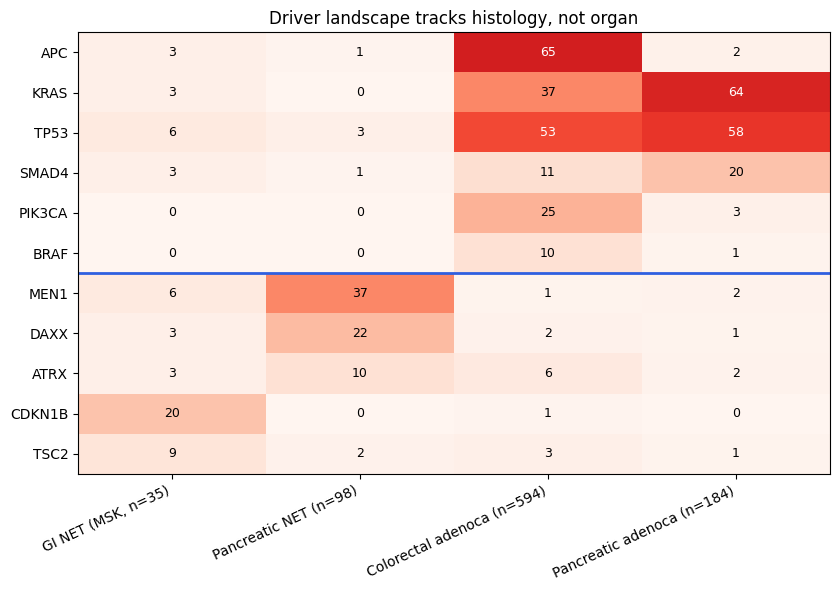

In [3]:
fig,ax=plt.subplots(figsize=(8.5,6))
im=ax.imshow(mat.values,aspect="auto",cmap="Reds",vmin=0,vmax=90)
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns,rotation=25,ha="right")
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]): ax.text(j,i,f"{mat.values[i,j]:.0f}",ha="center",va="center",fontsize=9,color="white" if mat.values[i,j]>45 else "black")
ax.axhline(len(ADENO)-0.5,color="#2f5fe0",lw=2); ax.set_title("Driver landscape tracks histology, not organ"); plt.tight_layout(); plt.show()

Adenocarcinomas are dominated by APC, KRAS, TP53, SMAD4. Both NET cohorts lack these and carry MEN1, DAXX, ATRX, CDKN1B, TSC2. A rectal NET shares its drivers with a pancreatic NET, not with the colorectal adenocarcinoma next to it.

## Transcriptomics: is the neuroendocrine program present in colorectal cancer?

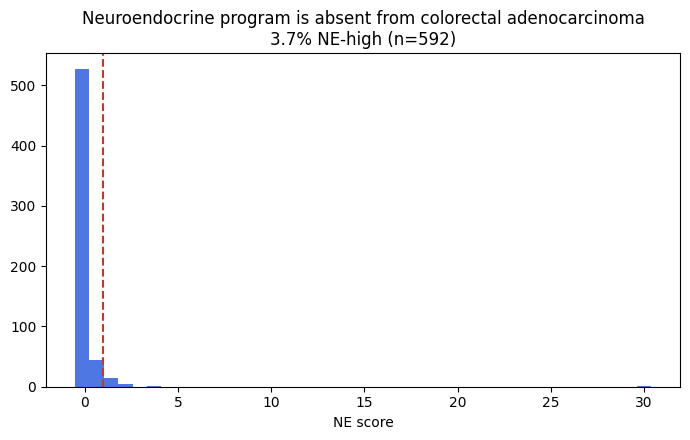

percent NE-high: 3.7


In [4]:
NE={1113:"CHGA",6855:"SYP",3642:"INSM1",6752:"SSTR2",429:"ASCL1",4760:"NEUROD1"}
S="coadread_tcga_pan_can_atlas_2018"
rp=next(p["molecularProfileId"] for p in get(f"{API}/studies/{S}/molecular-profiles") if "rna_seq" in p["molecularProfileId"] and "median_Zscores" in p["molecularProfileId"] and "normal" not in p["molecularProfileId"])
d=post(f"{API}/molecular-profiles/{rp}/molecular-data/fetch",{"sampleListId":S+"_all","entrezGeneIds":list(NE)})
bs=defaultdict(dict)
for r in d:
    if r.get("value") is not None: bs[r["sampleId"]][NE[r["entrezGeneId"]]]=r["value"]
ne=np.array([np.mean(list(v.values())) for v in bs.values() if len(v)>=4]); frac=round(100*float((ne>1).mean()),1)
plt.figure(figsize=(7,4.5)); plt.hist(ne,bins=40,color="#2f5fe0",alpha=.85); plt.axvline(1,color="#c0392b",ls="--")
plt.title(f"Neuroendocrine program is absent from colorectal adenocarcinoma\n{frac}% NE-high (n={len(ne)})"); plt.xlabel("NE score"); plt.tight_layout(); plt.show()
print("percent NE-high:",frac)

Only a few percent of colorectal adenocarcinomas are neuroendocrine-high. A rectal NET is neuroendocrine by definition. **Conclusion:** rectal NET should be treated as a NET (SSTR2 directed, Lu-177 DOTATATE), not as colorectal cancer. Full write-up: `docs/rectal_net_finding.md`.

---
*Research and educational analysis of public data, not medical advice. Group-level tumor biology, not any individual. Decisions rest with a qualified health care provider.*

*Anveshar. Developed by Dig Vijay Kumar Yarlagadda, [digvijayky.com](https://digvijayky.com).*